# Modèle Genre V3 - MobileNetV3Small

**Changements par rapport à V2:**

- **Backbone MobileNetV3Small** (au lieu d'EfficientNetB0)
- SE Attention conservé
- Focal Loss pour cas difficiles
- CLAHE pour normalisation de l'éclairage
- Fine-tuning en 2 phases

**Avantages de MobileNetV3Small:**

- ~2.5M paramètres (vs ~5.3M pour EfficientNetB0)
- 2-3x plus rapide sur mobile
- TFLite plus petit (~6MB vs ~15MB)


In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
if not (ROOT / 'config.py').exists():
    for parent in ROOT.parents:
        if (parent / 'config.py').exists():
            ROOT = parent
            break
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from config import (
    BASE_DIR, DATA_DIR, RAW_DIR, IMAGES_DIR, ARTIFACTS_DIR,
    NOTEBOOKS_DIR, ANDROID_ASSETS_DIR, TESTS_DIR, DIAGNOSTICS_DIR,
    ensure_kaggle_credentials, ensure_kaggle_dataset, describe_config,
    artifacts_for,
 )

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay

import numpy as np
import matplotlib.pyplot as plt
import json
import time
from PIL import Image
from pathlib import Path
import pandas as pd
import cv2
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_curve,
    auc,
    f1_score,
    classification_report,
    confusion_matrix,
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

print('Working dir set to', ROOT)
print(describe_config())


2026-03-25 09:42:28.536982: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 09:42:28.542071: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-25 09:42:28.655552: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-25 09:42:28.655660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-25 09:42:28.660304: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

TensorFlow version: 2.15.0
GPU disponible: []
Working dir set to /home/carld/face-analysis-deep-learning
{'BASE_DIR': '/home/carld/face-analysis-deep-learning', 'DATA_DIR': '/home/carld/face-analysis-deep-learning/data', 'RAW_DIR': '/home/carld/face-analysis-deep-learning/data/raw', 'IMAGES_DIR': '/home/carld/face-analysis-deep-learning/data/UTKFace', 'ARTIFACTS_DIR': '/home/carld/face-analysis-deep-learning/artifacts', 'ANDROID_ASSETS_DIR': '/home/carld/face-analysis-deep-learning/FacePredictor/app/src/main/assets', 'TESTS_DIR': '/home/carld/face-analysis-deep-learning/tests', 'DIAGNOSTICS_DIR': '/home/carld/face-analysis-deep-learning/diagnostics', 'DATASET_ID': 'jangedoo/utkface-new'}


2026-03-25 09:42:33.051875: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: UNKNOWN ERROR (100)


## Configuration


In [2]:
# Chemins
DATA_DIR = IMAGES_DIR
OUTPUT_DIR = artifacts_for("gender", "gender_model_v3_mobilenet")
ARTIFACTS_DIR = OUTPUT_DIR

# Classes
GENDER_MAP = {0: "Male", 1: "Female"}
NUM_CLASSES = 2
CLASS_NAMES = list(GENDER_MAP.values())

# Seed global pour reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Hyperparamètres
IMG_SIZE = 128
BATCH_SIZE = 32
WARMUP_EPOCHS = 25
FINETUNE_EPOCHS = 50
INITIAL_LR = 3e-4
FINETUNE_LR = 5e-6

# Focal Loss
FOCAL_GAMMA = 2.0
FOCAL_ALPHA = 0.5
LABEL_SMOOTHING = 0.05

# Validation
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

print(f"Dataset: {DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Configuration V3 (MobileNetV3Small):")
print(f"  - Backbone: MobileNetV3Small")
print(f"  - Classes: {CLASS_NAMES}")
print(f"  - Focal Loss: gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")

Dataset: /home/carld/face-analysis-deep-learning/data/UTKFace
Output: /home/carld/face-analysis-deep-learning/artifacts/gender/gender_model_v3_mobilenet
Configuration V3 (MobileNetV3Small):
  - Backbone: MobileNetV3Small
  - Classes: ['Male', 'Female']
  - Focal Loss: gamma=2.0, alpha=0.5


## Chargement des Données


In [3]:
def parse_utkface_filename(filepath):
    try:
        name = Path(filepath).name.split(".")[0]
        parts = name.split("_")
        if len(parts) < 2:
            return None
        gender = int(parts[1]) if parts[1].isdigit() else -1
        if gender not in [0, 1]:
            return None
        return {
            "filepath": str(filepath),
            "gender": gender,
            "gender_name": GENDER_MAP.get(gender, "Unknown"),
        }
    except Exception:
        return None


image_paths = list(DATA_DIR.glob("*.jpg*"))
print(f"Images trouvées: {len(image_paths)}")

records = []
for path in tqdm(image_paths, desc="Parsing"):
    record = parse_utkface_filename(path)
    if record:
        records.append(record)

df = pd.DataFrame(records)
print(f"Images valides: {len(df)}")
print(f"\nDistribution:")
print(df["gender_name"].value_counts())

Images trouvées: 23708


Parsing: 100%|██████████| 23708/23708 [00:00<00:00, 121877.86it/s]


Images valides: 23708

Distribution:
gender_name
Male      12391
Female    11317
Name: count, dtype: int64


## Split et Oversampling


In [4]:
X = df["filepath"].values
y = df["gender"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, stratify=y, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_SPLIT / (1 - TEST_SPLIT),
    stratify=y_temp,
    random_state=SEED,
)

print(f"Split:")
print(f"  - Train: {len(X_train)}")
print(f"  - Val: {len(X_val)}")
print(f"  - Test: {len(X_test)}")

Split:
  - Train: 18966
  - Val: 2371
  - Test: 2371


In [5]:
def oversample_minority_class(X, y):
    """Équilibre les classes par oversampling."""
    unique, counts = np.unique(y, return_counts=True)
    max_count = counts.max()

    X_resampled, y_resampled = [], []

    for cls in unique:
        mask = y == cls
        X_cls = X[mask]
        y_cls = y[mask]
        current_count = len(X_cls)

        if current_count < max_count:
            repeats = (max_count // current_count) + 1
            X_cls = np.tile(X_cls, repeats)[:max_count]
            y_cls = np.tile(y_cls, repeats)[:max_count]

        X_resampled.extend(X_cls)
        y_resampled.extend(y_cls)

    indices = np.random.permutation(len(X_resampled))
    return np.array(X_resampled)[indices], np.array(y_resampled)[indices]


X_train_balanced, y_train_balanced = oversample_minority_class(X_train, y_train)
print(f"\nAprès oversampling: {len(X_train_balanced)} (était {len(X_train)})")


Après oversampling: 19826 (était 18966)


## Focal Loss


In [6]:
class BinaryFocalLoss(keras.losses.Loss):
    """Focal Loss pour classification binaire."""

    def __init__(self, gamma=2.0, alpha=0.25, label_smoothing=0.0, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)

        y_true = tf.reshape(y_true, [-1])
        y_pred = tf.reshape(y_pred, [-1])

        if self.label_smoothing > 0:
            y_true = y_true * (1.0 - self.label_smoothing) + 0.5 * self.label_smoothing

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)

        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = tf.pow(1.0 - p_t, self.gamma)

        alpha_weight = y_true * self.alpha + (1 - y_true) * (1 - self.alpha)

        focal_loss = alpha_weight * focal_weight * bce

        return tf.reduce_mean(focal_loss)

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "gamma": self.gamma,
                "alpha": self.alpha,
                "label_smoothing": self.label_smoothing,
            }
        )
        return config


print("Focal Loss définie!")

Focal Loss définie!


## Data Pipeline avec CLAHE


In [7]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomBrightness(0.15),
        layers.RandomContrast(0.15),
    ],
    name="data_augmentation",
)


def apply_clahe(image):
    """Applique CLAHE pour normaliser l'éclairage."""
    if hasattr(image, "numpy"):
        image_np = image.numpy().astype(np.uint8)
    else:
        image_np = image.astype(np.uint8)

    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
    return enhanced.astype(np.float32)


def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)
    return img, label


def load_and_preprocess_with_clahe(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.py_function(apply_clahe, [img], tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])
    return img, label


def create_dataset(
    filepaths, labels, batch_size, shuffle=True, augment=False, use_clahe=False
):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(filepaths), seed=SEED, reshuffle_each_iteration=True
        )

    preprocess_fn = load_and_preprocess_with_clahe if use_clahe else load_and_preprocess
    ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = create_dataset(
    X_train_balanced,
    y_train_balanced,
    BATCH_SIZE,
    shuffle=True,
    augment=True,
    use_clahe=True,
)
val_ds = create_dataset(
    X_val, y_val, BATCH_SIZE, shuffle=False, augment=False, use_clahe=True
)
test_ds = create_dataset(
    X_test, y_test, BATCH_SIZE, shuffle=False, augment=False, use_clahe=True
)

print("Datasets créés avec CLAHE!")

Datasets créés avec CLAHE!


## Modèle avec SE Attention + MobileNetV3Small


In [8]:
def squeeze_excitation_block(x, ratio=16, name_prefix="se"):
    """Squeeze-Excitation attention block."""
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D(name=f"{name_prefix}_gap")(x)
    se = layers.Dense(filters // ratio, activation="relu", name=f"{name_prefix}_fc1")(
        se
    )
    se = layers.Dense(filters, activation="sigmoid", name=f"{name_prefix}_fc2")(se)
    se = layers.Reshape((1, 1, filters), name=f"{name_prefix}_reshape")(se)
    return layers.Multiply(name=f"{name_prefix}_scale")([x, se])


def build_gender_model_v3(img_size, trainable_backbone=False):
    """
    Modèle V3 avec MobileNetV3Small + SE attention.

    Changement: EfficientNetB0 -> MobileNetV3Small
    """
    inputs = layers.Input(shape=(img_size, img_size, 3), name="input_image")

    # ════════════════════════════════════════════════════════════
    # BACKBONE: MobileNetV3Small
    # ════════════════════════════════════════════════════════════
    backbone = MobileNetV3Small(
        include_top=False,
        weights="imagenet",
        input_shape=(img_size, img_size, 3),
        include_preprocessing=True,
        pooling=None,
    )
    backbone.trainable = trainable_backbone

    x = backbone(inputs)

    # SE attention
    x = squeeze_excitation_block(x, ratio=16, name_prefix="se")

    # Double pooling
    gap = layers.GlobalAveragePooling2D(name="gap")(x)
    gmp = layers.GlobalMaxPooling2D(name="gmp")(x)
    x = layers.Concatenate(name="concat_pool")([gap, gmp])

    # Head
    x = layers.Dense(
        256, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_1"
    )(x)
    x = layers.BatchNormalization(name="head_bn_1")(x)
    x = layers.Activation("relu", name="head_relu_1")(x)
    x = layers.Dropout(0.5, name="head_dropout_1")(x)

    x = layers.Dense(
        128, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_2"
    )(x)
    x = layers.BatchNormalization(name="head_bn_2")(x)
    x = layers.Activation("relu", name="head_relu_2")(x)
    x = layers.Dropout(0.4, name="head_dropout_2")(x)

    x = layers.Dense(64, kernel_regularizer=regularizers.l2(1e-4), name="head_dense_3")(
        x
    )
    x = layers.BatchNormalization(name="head_bn_3")(x)
    x = layers.Activation("relu", name="head_relu_3")(x)
    x = layers.Dropout(0.3, name="head_dropout_3")(x)

    outputs = layers.Dense(1, activation="sigmoid", name="gender_output")(x)

    model = Model(inputs, outputs, name="GenderModel_V3_MobileNet")
    return model, backbone


model, backbone = build_gender_model_v3(IMG_SIZE, trainable_backbone=False)

print(f"\n{'='*60}")
print(f"MODÈLE GENRE V3 - MobileNetV3Small")
print(f"{'='*60}")
print(f"Backbone: MobileNetV3Small ({len(backbone.layers)} couches)")
print(f"Total params: {model.count_params():,}")
model.summary()


MODÈLE GENRE V3 - MobileNetV3Small
Backbone: MobileNetV3Small (229 couches)
Total params: 1,319,381
Model: "GenderModel_V3_MobileNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_image (InputLayer)    [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 MobilenetV3small (Function  (None, 4, 4, 576)            939120    ['input_image[0][0]']         
 al)                                                                                              
                                                                                                  
 se_gap (GlobalAveragePooli  (None, 576)                  0         ['MobilenetV3small[0][0]']    
 ng2D)                                                                   

## Phase 1: Warmup


In [9]:
steps_per_epoch = len(X_train_balanced) // BATCH_SIZE
total_warmup_steps = steps_per_epoch * WARMUP_EPOCHS

warmup_lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_warmup_steps,
    alpha=0.1,
)

focal_loss = BinaryFocalLoss(
    gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA, label_smoothing=LABEL_SMOOTHING
)

model.compile(
    optimizer=AdamW(learning_rate=warmup_lr_schedule, weight_decay=1e-5),
    loss=focal_loss,
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

warmup_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "gender_v3_mobilenet_warmup.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

print(f"Phase 1: Warmup ({WARMUP_EPOCHS} epochs, backbone gelé)")

Phase 1: Warmup (25 epochs, backbone gelé)


In [10]:
warmup_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=WARMUP_EPOCHS,
    callbacks=warmup_callbacks,
    verbose=1,
)

Epoch 1/25


KeyboardInterrupt: 

## Phase 2: Fine-tuning


In [ ]:
backbone.trainable = True

# MobileNetV3Small a ~158 couches, on en dégèle 40
freeze_until = len(backbone.layers) - 40
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

trainable_count = sum(
    [tf.reduce_prod(w.shape).numpy() for w in model.trainable_weights]
)
print(f"Phase 2: Fine-tuning ({FINETUNE_EPOCHS} epochs)")
print(f"Couches dégelées: {len(backbone.layers) - freeze_until}/{len(backbone.layers)}")
print(f"Paramètres entraînables: {trainable_count:,}")

Phase 2: Fine-tuning (50 epochs)
Couches dégelées: 40/157
Paramètres entraînables: 1,093,677


In [ ]:
total_finetune_steps = steps_per_epoch * FINETUNE_EPOCHS

finetune_lr_schedule = CosineDecay(
    initial_learning_rate=FINETUNE_LR,
    decay_steps=total_finetune_steps,
    alpha=0.01,
)

model.compile(
    optimizer=AdamW(learning_rate=finetune_lr_schedule, weight_decay=1e-5),
    loss=focal_loss,
    metrics=["accuracy", keras.metrics.AUC(name="auc")],
)

finetune_callbacks = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max",
        verbose=1,
    ),
    callbacks.ModelCheckpoint(
        filepath=str(ARTIFACTS_DIR / "gender_v3_mobilenet_best.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1,
    ),
]

In [ ]:
finetune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINETUNE_EPOCHS,
    callbacks=finetune_callbacks,
    verbose=1,
)

Epoch 1/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7432 - auc: 0.8213 - loss: 0.0790
Epoch 1: val_accuracy improved from None to 0.80304, saving model to /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet_best.keras

Epoch 1: finished saving model to /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet_best.keras
620/620 ━━━━━━━━━━━━━━━━━━━━ 74s 94ms/step - accuracy: 0.7527 - auc: 0.8329 - loss: 0.0761 - val_accuracy: 0.8030 - val_auc: 0.9134 - val_loss: 0.0650
Epoch 2/50
620/620 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7655 - auc: 0.8492 - loss: 0.0721
Epoch 2: val_accuracy improved from 0.80304 to 0.82075, saving model to /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet_best.keras

Epoch 2: finished saving model to /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet_best.keras
620/620 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.7694 - auc: 0.8536 - loss: 0.0710 - val_accuracy: 0.8208 - val_auc: 0.9120 - val_loss: 0.0598
Epoch 3/5

## Évaluation et Optimisation du Seuil


In [ ]:
best_model = keras.models.load_model(
    ARTIFACTS_DIR / "gender_v3_mobilenet_best.keras",
    custom_objects={"BinaryFocalLoss": BinaryFocalLoss},
)

# Prédictions
y_pred_proba = best_model.predict(test_ds, verbose=1).flatten()
y_true = y_test

# Courbe ROC pour trouver le seuil optimal
fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Seuil optimal (Youden's J)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Seuil par défaut: 0.5")
print(f"Seuil optimal: {optimal_threshold:.3f}")
print(f"AUC-ROC: {roc_auc:.4f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step
Seuil par défaut: 0.5
Seuil optimal: 0.450
AUC-ROC: 0.9331


In [ ]:
# Utiliser le seuil optimal
BEST_THRESHOLD = optimal_threshold
y_pred = (y_pred_proba > BEST_THRESHOLD).astype(int)

accuracy = np.mean(y_pred == y_true)
f1 = f1_score(y_true, y_pred)

print(f"\n{'='*60}")
print(f"RÉSULTATS V3 (MobileNetV3Small) - seuil={BEST_THRESHOLD:.3f}")
print(f"{'='*60}")
print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - F1 Score: {f1:.4f}")
print(f"  - AUC-ROC: {roc_auc:.4f}")

print("\nRapport de classification:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


RÉSULTATS V3 (MobileNetV3Small) - seuil=0.450
  - Accuracy: 0.8456 (84.56%)
  - F1 Score: 0.8480
  - AUC-ROC: 0.9331

Rapport de classification:
              precision    recall  f1-score   support

        Male       0.90      0.79      0.84      1239
      Female       0.80      0.90      0.85      1132

    accuracy                           0.85      2371
   macro avg       0.85      0.85      0.85      2371
weighted avg       0.85      0.85      0.85      2371



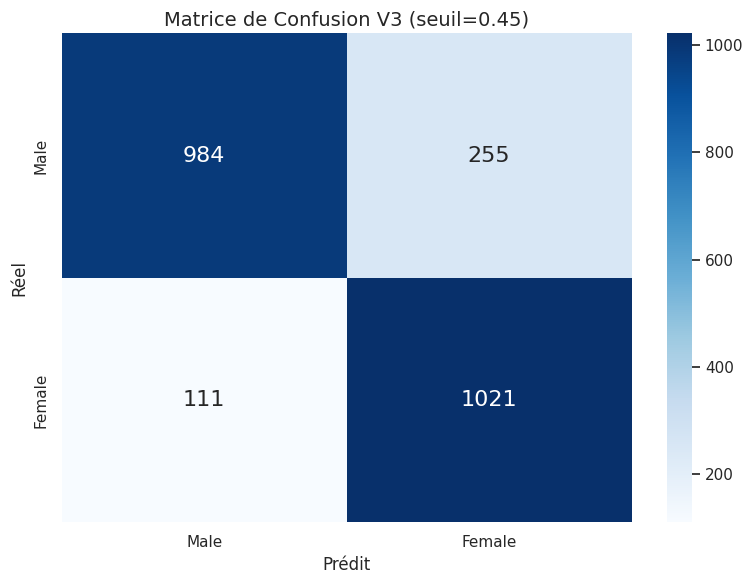

In [ ]:
# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    annot_kws={"size": 16},
)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title(f"Matrice de Confusion V3 (seuil={BEST_THRESHOLD:.2f})")

plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "gender_v3_mobilenet_confusion.png", dpi=150)
plt.show()

## Sauvegarde et Conversion TFLite


In [ ]:
final_model_path = ARTIFACTS_DIR / "gender_v3_mobilenet_final.keras"
best_model.save(final_model_path)
print(f"Modèle sauvegardé: {final_model_path}")

import json

model_info = {
    "version": "3.0",
    "backbone": "MobileNetV3Small",
    "img_size": IMG_SIZE,
    "classes": CLASS_NAMES,
    "class_map": {str(k): v for k, v in GENDER_MAP.items()},
    "threshold": float(BEST_THRESHOLD),
    "input_range": [0, 255],
    "preprocessing": {"clahe": True},
    "features": [
        "MobileNetV3Small backbone",
        "CLAHE",
        "SE Attention",
        "Focal Loss",
        "Optimized threshold",
    ],
    "metrics": {
        "accuracy": float(accuracy),
        "f1": float(f1),
        "auc_roc": float(roc_auc),
    },
}

with open(ARTIFACTS_DIR / "gender_v3_mobilenet_info.json", "w") as f:
    json.dump(model_info, f, indent=2)
print("Infos du modèle sauvegardées")

Modèle sauvegardé: /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet_final.keras
Infos du modèle sauvegardées


In [ ]:
# Conversion TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
tflite_model = converter.convert()

tflite_path = ARTIFACTS_DIR / "gender_v3_mobilenet.tflite"
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

tflite_size_mb = tflite_path.stat().st_size / 1024 / 1024
print(f"Modèle TFLite sauvegardé: {tflite_path}")
print(f"Taille: {tflite_size_mb:.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmpljtofssr/assets


INFO:tensorflow:Assets written to: /tmp/tmpljtofssr/assets


Saved artifact at '/tmp/tmpljtofssr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  126271284263824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860757840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860757648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860756112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860754384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860755728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860758608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860756688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860757264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860756880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126264860759760

W0000 00:00:1769594439.278106   63522 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1769594439.278132   63522 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1769594439.342818   63522 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


## Résumé Final


In [ ]:
print("=" * 60)
print("RÉSUMÉ DU MODÈLE GENRE V3 (MobileNetV3Small)")
print("=" * 60)
print(f"\nArchitecture: MobileNetV3Small + SE Attention + Dense Head")
print(f"Input size: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"Classes: {CLASS_NAMES}")
print(f"Seuil optimal: {BEST_THRESHOLD:.3f}")
print(f"\nPerformances sur le test set:")
print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - F1 Score: {f1:.4f}")
print(f"  - AUC-ROC: {roc_auc:.4f}")
print(f"\nTaille TFLite: {tflite_size_mb:.2f} MB")
print(f"\nFichiers sauvegardés:")
print(f"  - {final_model_path}")
print(f"  - {tflite_path}")
print("=" * 60)

RÉSUMÉ DU MODÈLE GENRE V3 (MobileNetV3Small)

Architecture: MobileNetV3Small + SE Attention + Dense Head
Input size: 128x128x3
Classes: ['Male', 'Female']
Seuil optimal: 0.450

Performances sur le test set:
  - Accuracy: 0.8456 (84.56%)
  - F1 Score: 0.8480
  - AUC-ROC: 0.9331

Taille TFLite: 2.55 MB

Fichiers sauvegardés:
  - /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet_final.keras
  - /home/optimalako/Projet/SAE/artifacts/gender_v3_mobilenet.tflite
